# Optimal integration comparison

Generate `optimal_integration_comparison.pdf` and the matching manuscript asset from the real bimodal psychometric fits and unimodal auditory/visual fits.

In [2]:
from pathlib import Path
import os

ROOT = Path.cwd()
os.environ.setdefault("MPLCONFIGDIR", str((ROOT / ".matplotlib_cache").resolve()))

import json
import numpy as np
import pandas as pd
import scipy.io
import matplotlib.pyplot as plt

from plot_style import *

FIG_DIR = ROOT / "ms_latex" / "assets" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

OUT_PATHS = [
    ROOT / "optimal_integration_comparison.pdf",
    ROOT / "optimal_integration_comparison.png",
    FIG_DIR / "optimal_integration_comparison.pdf",
    FIG_DIR / "optimal_integration_comparison.png",
]

MODEL_NOISE_OUT_PATHS = [
    ROOT / "optimal_integration_model_noise_comparison.pdf",
    ROOT / "optimal_integration_model_noise_comparison.png",
    FIG_DIR / "optimal_integration_model_noise_comparison.pdf",
    FIG_DIR / "optimal_integration_model_noise_comparison.png",
]

HIGH_NOISE = 1.2
LOW_NOISE = 0.1
SENSORY_TO_2IFC = np.sqrt(2.0)

MODEL_STYLE = {
    "fusionOnlyLogNorm": {"label": "Forced fusion", "color": "#2ca02c", "marker": "s"},
    "lognorm": {"label": "Causal inference", "color": "#600c70", "marker": "o"},
    "switchingFree": {"label": "Cue switching", "color": "#080529", "marker": "^"},
}
MODEL_ORDER = ["fusionOnlyLogNorm", "lognorm", "switchingFree"]

## Load complete participants

The old `plotAllModelFits.ipynb` tried to include `all` and `ln1`; those do not have all of the required unimodal `.mat` files. This notebook keeps only participants with a real bimodal psychometric fit, unimodal auditory fit, unimodal visual fit, and `*_all.csv` data file.

In [3]:
def complete_participants():
    participants = []
    for fit_path in sorted((ROOT / "psychometric_fits_real").glob("*/*_psychometricFits.json")):
        pid = fit_path.parent.name
        if pid == "all":
            continue

        required = [
            ROOT / "data" / f"{pid}_all.csv",
            ROOT / "data" / f"{pid}_auditory_fits.mat",
            ROOT / "data" / f"{pid}_visual_fits.mat",
            ROOT / "psychometric_fits_real" / pid / f"{pid}_psychometricFits.json",
        ]
        if all(path.exists() for path in required):
            participants.append(pid)
        else:
            missing = [str(path.relative_to(ROOT)) for path in required if not path.exists()]
            print(f"Skipping {pid}: missing {missing}")
    return participants


participant_ids = complete_participants()
participant_ids

Skipping ln1: missing ['data/ln1_auditory_fits.mat', 'data/ln1_visual_fits.mat']


['as', 'dt', 'hh', 'ip', 'ln2', 'mh', 'ml', 'mt', 'oy', 'qs', 'sx']

## Compute predicted and observed variability

`sigma_opt` is the reliability-weighted optimal prediction from unimodal auditory and visual variability. `sigma_AV` is the observed bimodal psychometric variability from the real bimodal task fits. Because both the unimodal inputs and the bimodal comparison target are 2IFC/task-level psychometric sigmas, the divide-by-`sqrt(2)` sensory conversion and the final multiply-by-`sqrt(2)` task conversion cancel in this plot.

In [4]:
def load_json(path):
    with open(path, "r") as f:
        return json.load(f)


def bimodal_sigma_av(pid, noise_level):
    fit_path = ROOT / "psychometric_fits_real" / pid / f"{pid}_psychometricFits.json"
    data_path = ROOT / "data" / f"{pid}_all.csv"

    fit_params = np.asarray(load_json(fit_path)["fitParams"], dtype=float)
    data = pd.read_csv(data_path)
    unique_noise = data["audNoise"].dropna().drop_duplicates().to_numpy(dtype=float)

    noise_idx = np.where(np.isclose(unique_noise, noise_level))[0]
    if len(noise_idx) == 0:
        raise ValueError(f"{pid}: noise level {noise_level} not found in {unique_noise}")

    # Psychometric fits use: [lambda_1, lambda_2, lambda_3, sigma_noise_1, ...]
    return fit_params[3 + int(noise_idx[0])]


def optimal_sigma(sigma_a, sigma_v):
    return 1.0 / np.sqrt(1.0 / sigma_a**2 + 1.0 / sigma_v**2)


rows = []
for pid in participant_ids:
    auditory = scipy.io.loadmat(ROOT / "data" / f"{pid}_auditory_fits.mat")["fittedParams"].flatten()
    visual = scipy.io.loadmat(ROOT / "data" / f"{pid}_visual_fits.mat")["fittedParams"].flatten()

    # Same indexing as the original plotAllModelFits.ipynb cell.
    sigma_a_high = float(auditory[1])
    sigma_a_low = float(auditory[2])
    sigma_v = float(visual[1])

    rows.append({
        "participant": pid,
        "sigma_opt_high": optimal_sigma(sigma_a_high, sigma_v),
        "sigma_av_high": bimodal_sigma_av(pid, HIGH_NOISE),
        "sigma_opt_low": optimal_sigma(sigma_a_low, sigma_v),
        "sigma_av_low": bimodal_sigma_av(pid, LOW_NOISE),
        "sigma_a_high": sigma_a_high,
        "sigma_a_low": sigma_a_low,
        "sigma_v": sigma_v,
    })

df_opt = pd.DataFrame(rows)
df_opt

,participant,sigma_opt_high,sigma_av_high,sigma_opt_low,sigma_av_low,sigma_a_high,sigma_a_low,sigma_v
0,as,1.121644,0.302350,0.233736,0.168996,3.500000,0.238427,1.184095
1,dt,0.691150,0.234254,0.303273,0.133873,2.222826,0.333675,0.727195
2,hh,0.491806,0.142131,0.009998,0.074853,2.130812,0.010000,0.505453
3,ip,0.331504,0.370451,0.288345,0.178136,0.521551,0.389126,0.429405
4,ln2,0.735016,0.131939,0.238134,0.280371,2.724685,0.250643,0.763314
5,mh,0.358282,0.321798,0.261545,0.295366,1.124372,0.362275,0.377985
6,ml,0.505970,0.239595,0.313105,0.216625,1.877348,0.389898,0.525412
7,mt,0.501338,0.213539,0.216108,0.104524,3.500000,0.238943,0.506562
8,oy,0.475555,0.267799,0.232213,0.198268,0.505136,0.235426,1.410379
9,qs,0.292646,0.354041,0.216204,0.154069,0.375843,0.244006,0.466389


## Plot observed bimodal noise and export

Saved optimal_integration_comparison.pdf
Saved optimal_integration_comparison.png
Saved ms_latex/assets/figures/optimal_integration_comparison.pdf
Saved ms_latex/assets/figures/optimal_integration_comparison.png


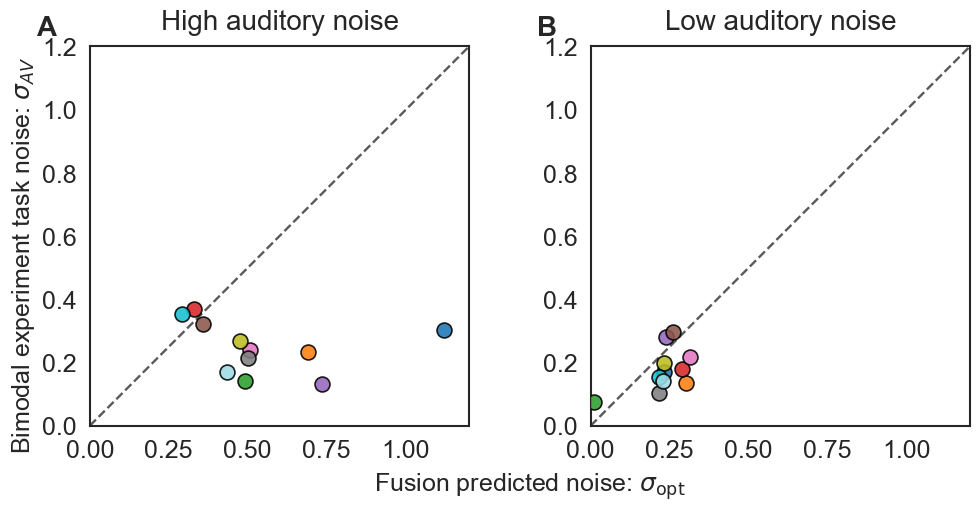

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5), constrained_layout=True)
colors = plt.get_cmap("tab20", len(df_opt))

panels = [
    ("High auditory noise", "sigma_opt_high", "sigma_av_high"),
    ("Low auditory noise", "sigma_opt_low", "sigma_av_low"),
]

all_values = np.r_[
    df_opt["sigma_opt_high"], df_opt["sigma_av_high"],
    df_opt["sigma_opt_low"], df_opt["sigma_av_low"],
]
plot_min = max(0, float(np.nanmin(all_values)) - 0.05)
plot_max = float(np.nanmax(all_values)) + 0.08

for ax, (title, x_col, y_col) in zip(axes, panels):
    for idx, row in df_opt.iterrows():
        ax.scatter(
            row[x_col], row[y_col],
            s=115,
            color=colors(idx),
            edgecolors="black",
            linewidths=1.2,
            alpha=0.88,
            zorder=3,
        )

    ax.plot([plot_min, plot_max], [plot_min, plot_max], "--", color="black", lw=1.7, alpha=0.65, zorder=1)
    ax.set_title(title, pad=12)
    ax.set_xlim(plot_min, plot_max)
    ax.set_ylim(plot_min, plot_max)
    ax.set_aspect("equal", adjustable="box")
    ax.tick_params(axis="both", which="major")
    for spine in ax.spines.values():
        spine.set_linewidth(1.5)

add_panel_labels(axes, x=-0.14, y=1.08)
fig.supxlabel(r"Fusion predicted noise: $\sigma_{\mathrm{opt}}$", fontsize=FONT_SIZE_LABEL)
fig.supylabel(r"Bimodal experiment task noise: $\sigma_{AV}$", x=-0.02, fontsize=FONT_SIZE_LABEL)

for out_path in OUT_PATHS:
    fig.savefig(out_path, dpi=400, bbox_inches="tight")
    print(f"Saved {out_path.relative_to(ROOT)}")

plt.show()

## Compare free-fitted model noise with optimal-fusion prediction

This companion figure uses the free psychometric refits of each model's simulated responses. For each participant, model, and auditory-noise condition, `sigma_plot` is averaged across conflict levels and plotted against the participant's optimal-fusion prediction from unimodal noise estimates.

In [6]:
def load_free_model_noise(pid, model_name):
    path = ROOT / "psychometric_fits_freeMuSigmaLambda_simulated" / pid / f"{pid}_{model_name}_psychometricFits.json"
    if not path.exists():
        print(f"Missing {path.relative_to(ROOT)}")
        return pd.DataFrame()

    payload = load_json(path)
    df = pd.DataFrame(payload["fitParamsByCondition"])
    df["participant"] = pid
    df["model"] = model_name
    return df


model_noise = pd.concat(
    [load_free_model_noise(pid, model) for pid in participant_ids for model in MODEL_ORDER],
    ignore_index=True,
)

model_noise_summary = (
    model_noise
    .groupby(["participant", "model", "audioNoise"], as_index=False)
    .agg(model_sigma=("sigma_plot", "mean"), n_conflicts=("conflict", "nunique"))
)

opt_long = pd.concat([
    df_opt[["participant", "sigma_opt_high"]].rename(columns={"sigma_opt_high": "sigma_opt"}).assign(audioNoise=HIGH_NOISE),
    df_opt[["participant", "sigma_opt_low"]].rename(columns={"sigma_opt_low": "sigma_opt"}).assign(audioNoise=LOW_NOISE),
], ignore_index=True)

model_noise_summary = model_noise_summary.merge(opt_long, on=["participant", "audioNoise"], how="left")
model_noise_summary

,participant,model,audioNoise,model_sigma,n_conflicts,sigma_opt
0,as,fusionOnlyLogNorm,0.1,0.335367,7,0.233736
1,as,fusionOnlyLogNorm,1.2,0.555538,7,1.121644
2,as,lognorm,0.1,0.291618,7,0.233736
3,as,lognorm,1.2,0.575040,7,1.121644
4,as,switchingFree,0.1,0.309881,7,0.233736
...,...,...,...,...,...,...
61,sx,fusionOnlyLogNorm,1.2,0.455811,7,0.435862
62,sx,lognorm,0.1,0.354374,7,0.228680
63,sx,lognorm,1.2,0.428867,7,0.435862
64,sx,switchingFree,0.1,0.339178,7,0.228680


Saved optimal_integration_model_noise_comparison.pdf
Saved optimal_integration_model_noise_comparison.png
Saved ms_latex/assets/figures/optimal_integration_model_noise_comparison.pdf
Saved ms_latex/assets/figures/optimal_integration_model_noise_comparison.png


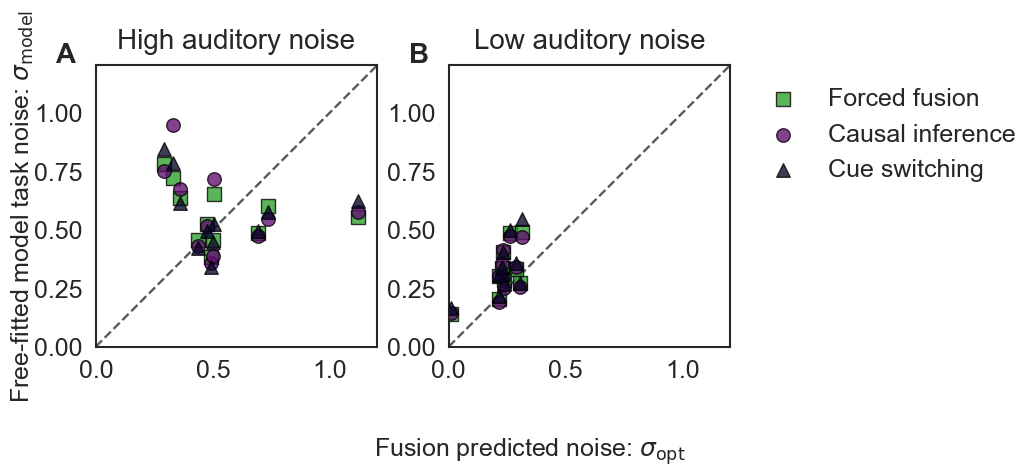

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5), constrained_layout=True)
noise_panels = [(HIGH_NOISE, "High auditory noise"), (LOW_NOISE, "Low auditory noise")]

all_values = np.r_[model_noise_summary["sigma_opt"], model_noise_summary["model_sigma"]]
plot_min = max(0, float(np.nanmin(all_values)) - 0.05)
plot_max = float(np.nanmax(all_values)) + 0.08

for ax, (noise, title) in zip(axes, noise_panels):
    sub_noise = model_noise_summary[np.isclose(model_noise_summary["audioNoise"], noise)]
    for model_name in MODEL_ORDER:
        style = MODEL_STYLE[model_name]
        sub = sub_noise[sub_noise["model"] == model_name]
        ax.scatter(
            sub["sigma_opt"], sub["model_sigma"],
            s=95,
            color=style["color"],
            marker=style["marker"],
            edgecolors="black",
            linewidths=1.0,
            alpha=0.78,
            label=style["label"],
            zorder=3,
        )

    ax.plot([plot_min, plot_max], [plot_min, plot_max], "--", color="black", lw=1.7, alpha=0.65, zorder=1)
    ax.set_title(title, pad=12)
    ax.set_xlim(plot_min, plot_max)
    ax.set_ylim(plot_min, plot_max)
    ax.set_aspect("equal", adjustable="box")
    for spine in ax.spines.values():
        spine.set_linewidth(1.5)

add_panel_labels(axes, x=-0.14, y=1.08)
axes[1].legend(frameon=False, loc="upper left", bbox_to_anchor=(1.02, 1.0))
fig.supxlabel(r"Fusion predicted noise: $\sigma_{\mathrm{opt}}$", y=-0.02, fontsize=FONT_SIZE_LABEL)
fig.supylabel(r"Free-fitted model task noise: $\sigma_{\mathrm{model}}$", x=-0.02, fontsize=FONT_SIZE_LABEL)

for out_path in MODEL_NOISE_OUT_PATHS:
    fig.savefig(out_path, dpi=400, bbox_inches="tight")
    print(f"Saved {out_path.relative_to(ROOT)}")

plt.show()

## Sensory-noise diagnostics from the fitted models

The figures below ask a slightly different question from the psychometric-refit comparison above. Instead of refitting psychometric functions to simulated model responses, we take each model's fitted sensory-noise parameters directly: auditory noise in the low-noise condition, auditory noise in the high-noise condition, and shared visual noise. From these values we compute the fusion-equivalent prediction

$$
\sigma_{\mathrm{fusion,2IFC}} = \sqrt{2}\left(\frac{1}{\sigma_a^2} + \frac{1}{\sigma_v^2}\right)^{-1/2}.
$$

The model parameters are internal single-interval sensory-noise parameters, whereas the free psychometric noise fitted directly to the bimodal data is a 2IFC/task-level sigma. Therefore the model-implied fused sensory noise is multiplied by `sqrt(2)` before comparison with `sigma_AV`.

In [8]:
MODEL_FIT_OUT_PATHS = [
    ROOT / "model_fusion_noise_vs_bimodal_data.pdf",
    ROOT / "model_fusion_noise_vs_bimodal_data.png",
    FIG_DIR / "model_fusion_noise_vs_bimodal_data.pdf",
    FIG_DIR / "model_fusion_noise_vs_bimodal_data.png",
]

MODEL_CORR_OUT_PATHS = [
    ROOT / "model_noise_prediction_correlations.pdf",
    ROOT / "model_noise_prediction_correlations.png",
    FIG_DIR / "model_noise_prediction_correlations.pdf",
    FIG_DIR / "model_noise_prediction_correlations.png",
]

MODEL_ERROR_OUT_PATHS = [
    ROOT / "model_noise_prediction_error_summary.pdf",
    ROOT / "model_noise_prediction_error_summary.png",
    FIG_DIR / "model_noise_prediction_error_summary.pdf",
    FIG_DIR / "model_noise_prediction_error_summary.png",
]

MODEL_SIGMA_OUT_PATHS = [
    ROOT / "model_fitted_sigma_components.pdf",
    ROOT / "model_fitted_sigma_components.png",
    FIG_DIR / "model_fitted_sigma_components.pdf",
    FIG_DIR / "model_fitted_sigma_components.png",
]

In [9]:
def load_bimodal_free_noise():
    frames = []
    for pid in participant_ids:
        path = ROOT / "psychometric_fits_freeMuSigmaLambda_real" / pid / f"{pid}_psychometricFits.json"
        if not path.exists():
            print(f"Missing {path.relative_to(ROOT)}")
            continue
        payload = load_json(path)
        df = pd.DataFrame(payload["fitParamsByCondition"])
        df["participant"] = pid
        frames.append(df)

    free_noise = pd.concat(frames, ignore_index=True)
    return (
        free_noise
        .groupby(["participant", "audioNoise"], as_index=False)
        .agg(
            bimodal_sigma=("sigma_plot", "mean"),
            bimodal_sigma_sem=("sigma_plot", "sem"),
            n_conflicts=("conflict", "nunique"),
        )
    )


def parse_model_fit_file(path):
    parts = path.name.replace(".json", "").split("_")
    return parts[1], parts[2], parts[3]


def fitted_sigma_components(model_name, params):
    params = np.asarray(params, dtype=float)
    if model_name == "fusionOnlyLogNorm":
        sigma_a_low, sigma_v, sigma_a_high = params[1], params[2], params[3]
    elif model_name == "lognorm":
        sigma_a_low, sigma_v, sigma_a_high = params[1], params[2], params[4]
    elif model_name == "switchingFree":
        sigma_a_low, sigma_v, sigma_a_high = params[1], params[2], params[4]
    else:
        raise ValueError(f"Unexpected model: {model_name}")

    return dict(
        sigma_a_low=float(sigma_a_low),
        sigma_a_high=float(sigma_a_high),
        sigma_v=float(sigma_v),
        sigma_fusion_low_sensory=optimal_sigma(float(sigma_a_low), float(sigma_v)),
        sigma_fusion_high_sensory=optimal_sigma(float(sigma_a_high), float(sigma_v)),
        sigma_fusion_low=SENSORY_TO_2IFC * optimal_sigma(float(sigma_a_low), float(sigma_v)),
        sigma_fusion_high=SENSORY_TO_2IFC * optimal_sigma(float(sigma_a_high), float(sigma_v)),
    )


def load_free_sigma_model_components():
    rows = []
    wanted = set(MODEL_ORDER)
    for path in sorted((ROOT / "model_fits").glob("**/*.json")):
        filename = path.name
        filename_lower = filename.lower()
        if any(token in filename_lower for token in ("all", "ln1", "lnd1", "loglinear")):
            continue

        model_name, lapse_tag, prior_tag = parse_model_fit_file(path)
        if model_name not in wanted:
            continue
        if lapse_tag != "LapseFix" or prior_tag != "sharedPrior":
            continue

        payload = load_json(path)
        pid = str(payload.get("participantID", path.parent.name)).lower()
        if pid not in participant_ids:
            continue

        row = dict(participant=pid, model=model_name, fit_file=str(path.relative_to(ROOT)))
        row.update(fitted_sigma_components(model_name, payload["fittedParams"]))
        rows.append(row)

    components = pd.DataFrame(rows)
    components["model_label"] = components["model"].map(lambda m: MODEL_STYLE[m]["label"])
    return components


bimodal_noise = load_bimodal_free_noise()
model_components = load_free_sigma_model_components()

model_pred_long = pd.concat([
    model_components[["participant", "model", "model_label", "sigma_a_low", "sigma_v", "sigma_fusion_low"]]
    .rename(columns={"sigma_a_low": "sigma_a", "sigma_fusion_low": "sigma_fusion"})
    .assign(audioNoise=LOW_NOISE, noise_label="Low auditory noise"),
    model_components[["participant", "model", "model_label", "sigma_a_high", "sigma_v", "sigma_fusion_high"]]
    .rename(columns={"sigma_a_high": "sigma_a", "sigma_fusion_high": "sigma_fusion"})
    .assign(audioNoise=HIGH_NOISE, noise_label="High auditory noise"),
], ignore_index=True)

noise_diag = model_pred_long.merge(bimodal_noise, on=["participant", "audioNoise"], how="left")
noise_diag["error"] = noise_diag["sigma_fusion"] - noise_diag["bimodal_sigma"]
noise_diag["abs_error"] = noise_diag["error"].abs()

print(f"Rows: {len(noise_diag)}; participants: {sorted(noise_diag['participant'].unique())}")
noise_diag.head()

Rows: 132; participants: ['as', 'dt', 'hh', 'ip', 'ln2', 'mh', 'ml', 'mt', 'oy', 'qs', 'sx']


,participant,model,model_label,sigma_a,sigma_v,sigma_fusion,audioNoise,noise_label,bimodal_sigma,bimodal_sigma_sem,n_conflicts,error,abs_error
0,as,fusionOnlyLogNorm,Forced fusion,0.238490,0.593979,0.312990,0.1,Low auditory noise,0.324444,0.023273,7,-0.011454,0.011454
1,as,lognorm,Causal inference,0.241329,0.606782,0.317130,0.1,Low auditory noise,0.324444,0.023273,7,-0.007314,0.007314
2,as,switchingFree,Cue switching,0.248199,0.000113,0.000160,0.1,Low auditory noise,0.324444,0.023273,7,-0.324284,0.324284
3,dt,fusionOnlyLogNorm,Forced fusion,0.183367,0.461636,0.241004,0.1,Low auditory noise,0.314685,0.038647,7,-0.073681,0.073681
4,dt,lognorm,Causal inference,0.217073,0.335323,0.257703,0.1,Low auditory noise,0.314685,0.038647,7,-0.056982,0.056982


Saved model_fusion_noise_vs_bimodal_data.pdf
Saved model_fusion_noise_vs_bimodal_data.png
Saved ms_latex/assets/figures/model_fusion_noise_vs_bimodal_data.pdf
Saved ms_latex/assets/figures/model_fusion_noise_vs_bimodal_data.png


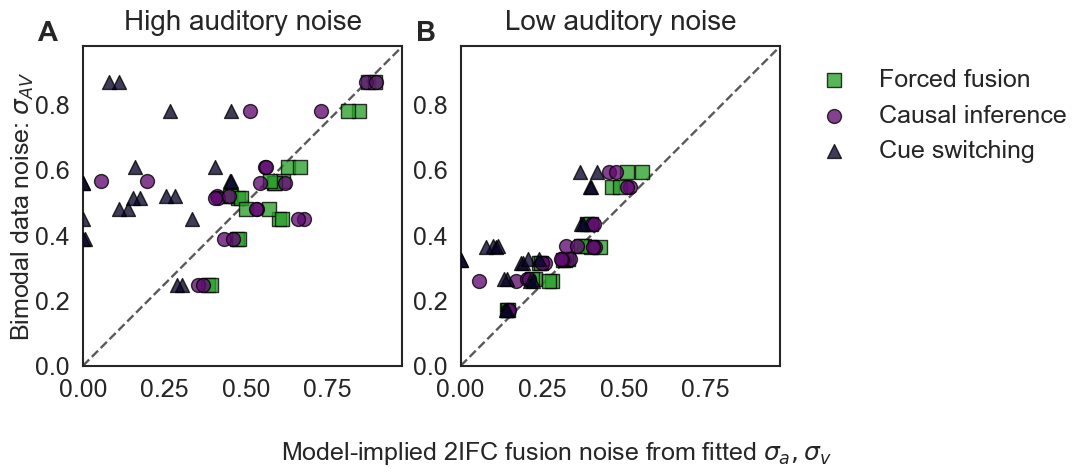

In [10]:
# Plot 1: bimodal data noise vs. model-implied fusion-equivalent noise.
fig, axes = plt.subplots(1, 2, figsize=(10.5, 5.0), constrained_layout=True)
noise_panels = [(HIGH_NOISE, "High auditory noise"), (LOW_NOISE, "Low auditory noise")]
all_values = np.r_[noise_diag["sigma_fusion"], noise_diag["bimodal_sigma"]]
plot_min = max(0, float(np.nanmin(all_values)) - 0.05)
plot_max = float(np.nanmax(all_values)) + 0.08

for ax, (noise, title) in zip(axes, noise_panels):
    sub_noise = noise_diag[np.isclose(noise_diag["audioNoise"], noise)]
    for model_name in MODEL_ORDER:
        style = MODEL_STYLE[model_name]
        sub = sub_noise[sub_noise["model"] == model_name]
        ax.scatter(
            sub["sigma_fusion"], sub["bimodal_sigma"],
            s=100,
            color=style["color"],
            marker=style["marker"],
            edgecolors="black",
            linewidths=1.0,
            alpha=0.78,
            label=style["label"],
            zorder=3,
        )

    ax.plot([plot_min, plot_max], [plot_min, plot_max], "--", color="black", lw=1.7, alpha=0.65, zorder=1)
    ax.set_title(title, pad=12)
    ax.set_xlim(plot_min, plot_max)
    ax.set_ylim(plot_min, plot_max)
    ax.set_aspect("equal", adjustable="box")
    for spine in ax.spines.values():
        spine.set_linewidth(1.5)

add_panel_labels(axes, x=-0.14, y=1.08)
axes[1].legend(frameon=False, loc="upper left", bbox_to_anchor=(1.02, 1.0))
fig.supxlabel(r"Model-implied 2IFC fusion noise from fitted $\sigma_a, \sigma_v$", y=-0.02, fontsize=FONT_SIZE_LABEL)
fig.supylabel(r"Bimodal data noise: $\sigma_{AV}$", x=-0.02, fontsize=FONT_SIZE_LABEL)

for out_path in MODEL_FIT_OUT_PATHS:
    fig.savefig(out_path, dpi=400, bbox_inches="tight")
    print(f"Saved {out_path.relative_to(ROOT)}")

plt.show()

               model       model_label  pearson_r     pearson_p  spearman_r  \
0  fusionOnlyLogNorm     Forced fusion   0.937595  7.021889e-21    0.908104   
1            lognorm  Causal inference   0.754804  3.245646e-09    0.734326   
2      switchingFree     Cue switching   0.252884  9.768213e-02    0.254743   

     spearman_p      rmse       mae  
0  1.775864e-17  0.063702  0.049408  
1  1.402336e-08  0.131551  0.086829  
2  9.515972e-02  0.313310  0.252734  
Saved model_noise_prediction_correlations.pdf
Saved model_noise_prediction_correlations.png
Saved ms_latex/assets/figures/model_noise_prediction_correlations.pdf
Saved ms_latex/assets/figures/model_noise_prediction_correlations.png


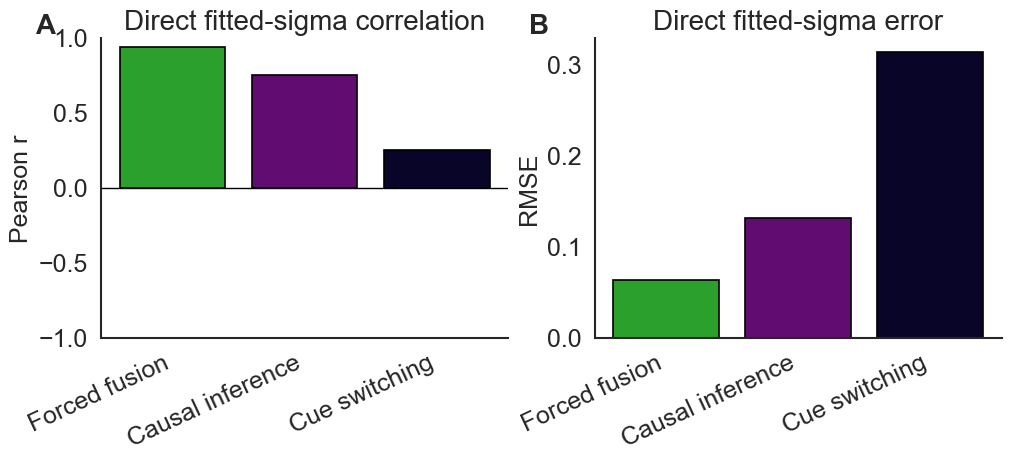

In [11]:
# Plot 2: correlation between each model's predictions and the bimodal data noise.
from scipy.stats import pearsonr, spearmanr

corr_rows = []
for model_name in MODEL_ORDER:
    sub = noise_diag[noise_diag["model"] == model_name].dropna(subset=["sigma_fusion", "bimodal_sigma"])
    pearson_r, pearson_p = pearsonr(sub["sigma_fusion"], sub["bimodal_sigma"])
    spearman_r, spearman_p = spearmanr(sub["sigma_fusion"], sub["bimodal_sigma"])
    rmse = float(np.sqrt(np.mean((sub["sigma_fusion"] - sub["bimodal_sigma"]) ** 2)))
    mae = float(np.mean(np.abs(sub["sigma_fusion"] - sub["bimodal_sigma"])))
    corr_rows.append(dict(
        model=model_name,
        model_label=MODEL_STYLE[model_name]["label"],
        pearson_r=pearson_r,
        pearson_p=pearson_p,
        spearman_r=spearman_r,
        spearman_p=spearman_p,
        rmse=rmse,
        mae=mae,
    ))

corr_df = pd.DataFrame(corr_rows)
print(corr_df)

fig, axes = plt.subplots(1, 2, figsize=(10, 4.5), constrained_layout=True)
x = np.arange(len(MODEL_ORDER))
colors = [MODEL_STYLE[m]["color"] for m in MODEL_ORDER]
labels = [MODEL_STYLE[m]["label"] for m in MODEL_ORDER]

axes[0].bar(x, corr_df.set_index("model").loc[MODEL_ORDER, "pearson_r"], color=colors, edgecolor="black", linewidth=1.2)
axes[0].axhline(0, color="black", lw=1)
axes[0].set_ylim(-1, 1)
axes[0].set_ylabel("Pearson r")
axes[0].set_title("Direct fitted-sigma correlation")

axes[1].bar(x, corr_df.set_index("model").loc[MODEL_ORDER, "rmse"], color=colors, edgecolor="black", linewidth=1.2)
axes[1].set_ylabel("RMSE")
axes[1].set_title("Direct fitted-sigma error")

for ax in axes:
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=25, ha="right")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

add_panel_labels(axes, x=-0.16, y=1.08)

for out_path in MODEL_CORR_OUT_PATHS:
    fig.savefig(out_path, dpi=400, bbox_inches="tight")
    print(f"Saved {out_path.relative_to(ROOT)}")

plt.show()

Saved model_noise_prediction_error_summary.pdf
Saved model_noise_prediction_error_summary.png
Saved ms_latex/assets/figures/model_noise_prediction_error_summary.pdf
Saved ms_latex/assets/figures/model_noise_prediction_error_summary.png


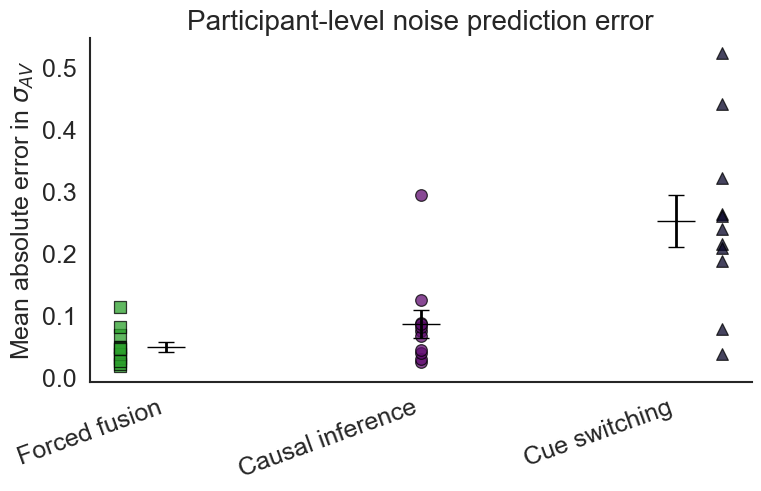

In [12]:
# Plot 3: participant-level absolute errors, so the winning model is visible without hiding individual variability.
fig, ax = plt.subplots(figsize=(7.5, 4.8), constrained_layout=True)
jitter = {"fusionOnlyLogNorm": -0.18, "lognorm": 0.0, "switchingFree": 0.18}

for model_name in MODEL_ORDER:
    style = MODEL_STYLE[model_name]
    sub = noise_diag[noise_diag["model"] == model_name]
    # Average high/low condition error within participant.
    pp = sub.groupby("participant", as_index=False)["abs_error"].mean()
    xpos = np.full(len(pp), MODEL_ORDER.index(model_name), dtype=float) + jitter[model_name]
    ax.scatter(
        xpos,
        pp["abs_error"],
        s=70,
        color=style["color"],
        marker=style["marker"],
        edgecolors="black",
        linewidths=0.9,
        alpha=0.75,
        zorder=3,
    )
    mean_err = pp["abs_error"].mean()
    sem_err = pp["abs_error"].sem()
    ax.errorbar(
        MODEL_ORDER.index(model_name), mean_err, yerr=sem_err,
        fmt="_", markersize=28, color="black", elinewidth=2.0, capsize=6, zorder=4,
    )

ax.set_xticks(np.arange(len(MODEL_ORDER)))
ax.set_xticklabels([MODEL_STYLE[m]["label"] for m in MODEL_ORDER], rotation=20, ha="right")
ax.set_ylabel(r"Mean absolute error in $\sigma_{AV}$")
ax.set_title("Participant-level noise prediction error")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

for out_path in MODEL_ERROR_OUT_PATHS:
    fig.savefig(out_path, dpi=400, bbox_inches="tight")
    print(f"Saved {out_path.relative_to(ROOT)}")

plt.show()

Saved model_fitted_sigma_components.pdf
Saved model_fitted_sigma_components.png
Saved ms_latex/assets/figures/model_fitted_sigma_components.pdf
Saved ms_latex/assets/figures/model_fitted_sigma_components.png


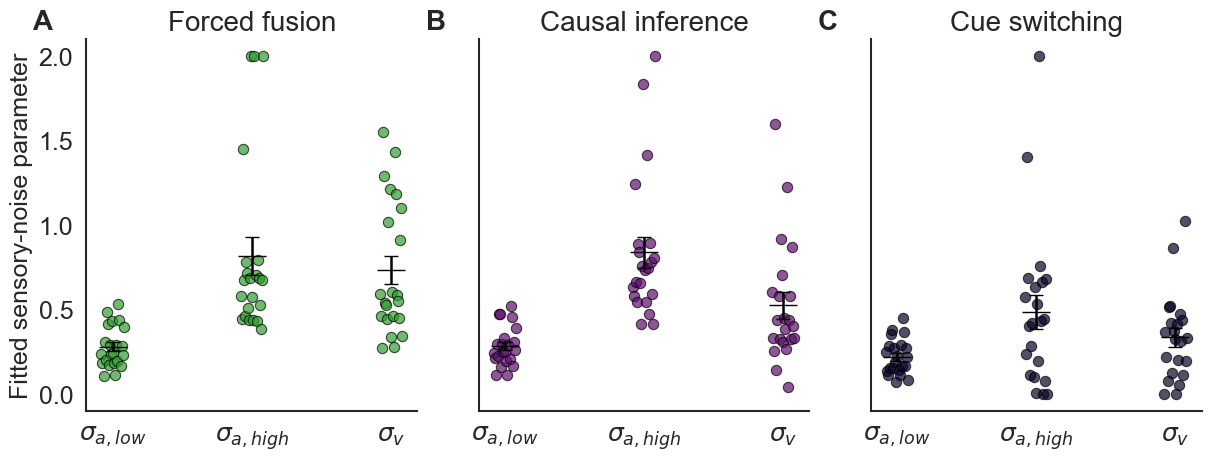

In [13]:
# Plot 4: fitted sensory-noise components themselves.
component_long = model_components.melt(
    id_vars=["participant", "model", "model_label"],
    value_vars=["sigma_a_low", "sigma_a_high", "sigma_v"],
    var_name="component",
    value_name="sigma",
)
component_order = ["sigma_a_low", "sigma_a_high", "sigma_v"]
component_labels = {
    "sigma_a_low": r"$\sigma_{a,low}$",
    "sigma_a_high": r"$\sigma_{a,high}$",
    "sigma_v": r"$\sigma_v$",
}

fig, axes = plt.subplots(1, len(MODEL_ORDER), figsize=(12, 4.5), sharey=True, constrained_layout=True)
for ax, model_name in zip(axes, MODEL_ORDER):
    style = MODEL_STYLE[model_name]
    sub = component_long[component_long["model"] == model_name]
    for idx, component in enumerate(component_order):
        vals = sub[sub["component"] == component]["sigma"].to_numpy(float)
        x_jit = np.full(len(vals), idx, dtype=float) + np.linspace(-0.08, 0.08, len(vals))
        ax.scatter(x_jit, vals, s=55, color=style["color"], edgecolors="black", linewidths=0.8, alpha=0.7)
        ax.errorbar(idx, np.nanmean(vals), yerr=pd.Series(vals).sem(), fmt="_", color="black", markersize=20, capsize=5, elinewidth=1.8)
    ax.set_title(style["label"])
    ax.set_xticks(np.arange(len(component_order)))
    ax.set_xticklabels([component_labels[c] for c in component_order])
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

axes[0].set_ylabel("Fitted sensory-noise parameter")
add_panel_labels(axes, x=-0.16, y=1.08)

for out_path in MODEL_SIGMA_OUT_PATHS:
    fig.savefig(out_path, dpi=400, bbox_inches="tight")
    print(f"Saved {out_path.relative_to(ROOT)}")

plt.show()

## Output-level noise capture

The direct fitted-sigma diagnostic above is useful, but it is not the whole story. The models transform sensory noise, lapse, causal prior/switching parameters, and decision variability into predicted behavioral responses. To evaluate whether a model captures the observed task noise at the behavioral-output level, we use the free psychometric refits to each model's simulated responses and compare those simulated-response noise estimates with the real bimodal noise estimates.

In [14]:
MODEL_SIM_CORR_OUT_PATHS = [
    ROOT / "model_simulated_response_noise_correlations.pdf",
    ROOT / "model_simulated_response_noise_correlations.png",
    FIG_DIR / "model_simulated_response_noise_correlations.pdf",
    FIG_DIR / "model_simulated_response_noise_correlations.png",
]

MODEL_METRIC_COMPARE_OUT_PATHS = [
    ROOT / "model_noise_metric_comparison.pdf",
    ROOT / "model_noise_metric_comparison.png",
    FIG_DIR / "model_noise_metric_comparison.pdf",
    FIG_DIR / "model_noise_metric_comparison.png",
]

               model       model_label  pearson_r     pearson_p  spearman_r  \
0  fusionOnlyLogNorm     Forced fusion   0.902608  9.221840e-09    0.893845   
1            lognorm  Causal inference   0.903698  8.278887e-09    0.898363   
2      switchingFree     Cue switching   0.959517  1.804879e-12    0.942405   

     spearman_p      rmse       mae  
0  2.102466e-08  0.073834  0.054887  
1  1.387615e-08  0.082371  0.059853  
2  5.708480e-11  0.048551  0.038010  
Saved model_simulated_response_noise_correlations.pdf
Saved model_simulated_response_noise_correlations.png
Saved ms_latex/assets/figures/model_simulated_response_noise_correlations.pdf
Saved ms_latex/assets/figures/model_simulated_response_noise_correlations.png


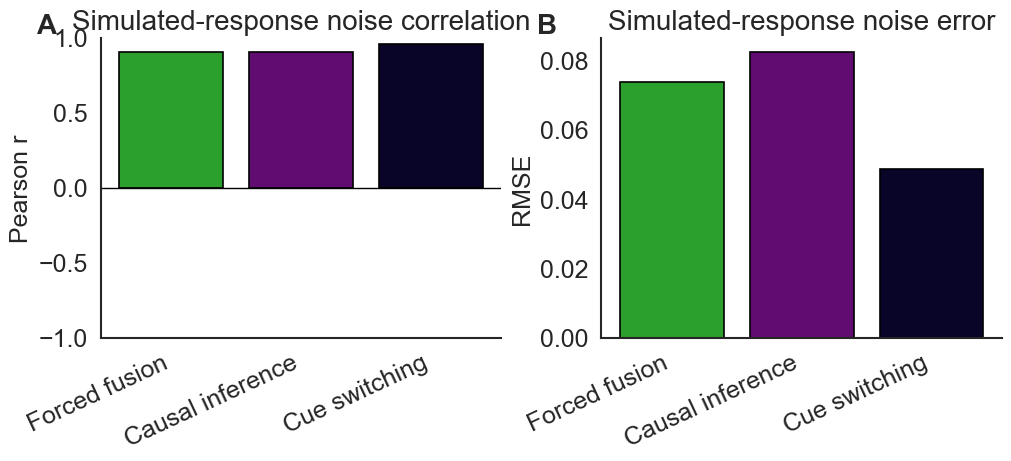

In [15]:
# Correlation/error for the simulated-response psychometric noise estimates.
sim_noise_diag = model_noise_summary.merge(bimodal_noise, on=["participant", "audioNoise"], how="left")
sim_noise_diag["error"] = sim_noise_diag["model_sigma"] - sim_noise_diag["bimodal_sigma"]
sim_noise_diag["abs_error"] = sim_noise_diag["error"].abs()

sim_corr_rows = []
for model_name in MODEL_ORDER:
    sub = sim_noise_diag[sim_noise_diag["model"] == model_name].dropna(subset=["model_sigma", "bimodal_sigma"])
    pearson_r, pearson_p = pearsonr(sub["model_sigma"], sub["bimodal_sigma"])
    spearman_r, spearman_p = spearmanr(sub["model_sigma"], sub["bimodal_sigma"])
    rmse = float(np.sqrt(np.mean((sub["model_sigma"] - sub["bimodal_sigma"]) ** 2)))
    mae = float(np.mean(np.abs(sub["model_sigma"] - sub["bimodal_sigma"])))
    sim_corr_rows.append(dict(
        model=model_name,
        model_label=MODEL_STYLE[model_name]["label"],
        pearson_r=pearson_r,
        pearson_p=pearson_p,
        spearman_r=spearman_r,
        spearman_p=spearman_p,
        rmse=rmse,
        mae=mae,
    ))

sim_corr_df = pd.DataFrame(sim_corr_rows)
print(sim_corr_df)

fig, axes = plt.subplots(1, 2, figsize=(10, 4.5), constrained_layout=True)
x = np.arange(len(MODEL_ORDER))
colors = [MODEL_STYLE[m]["color"] for m in MODEL_ORDER]
labels = [MODEL_STYLE[m]["label"] for m in MODEL_ORDER]

axes[0].bar(x, sim_corr_df.set_index("model").loc[MODEL_ORDER, "pearson_r"], color=colors, edgecolor="black", linewidth=1.2)
axes[0].axhline(0, color="black", lw=1)
axes[0].set_ylim(-1, 1)
axes[0].set_ylabel("Pearson r")
axes[0].set_title("Simulated-response noise correlation")

axes[1].bar(x, sim_corr_df.set_index("model").loc[MODEL_ORDER, "rmse"], color=colors, edgecolor="black", linewidth=1.2)
axes[1].set_ylabel("RMSE")
axes[1].set_title("Simulated-response noise error")

for ax in axes:
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=25, ha="right")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

add_panel_labels(axes, x=-0.16, y=1.08)

for out_path in MODEL_SIM_CORR_OUT_PATHS:
    fig.savefig(out_path, dpi=400, bbox_inches="tight")
    print(f"Saved {out_path.relative_to(ROOT)}")

plt.show()

Saved model_noise_metric_comparison.pdf
Saved model_noise_metric_comparison.png
Saved ms_latex/assets/figures/model_noise_metric_comparison.pdf
Saved ms_latex/assets/figures/model_noise_metric_comparison.png


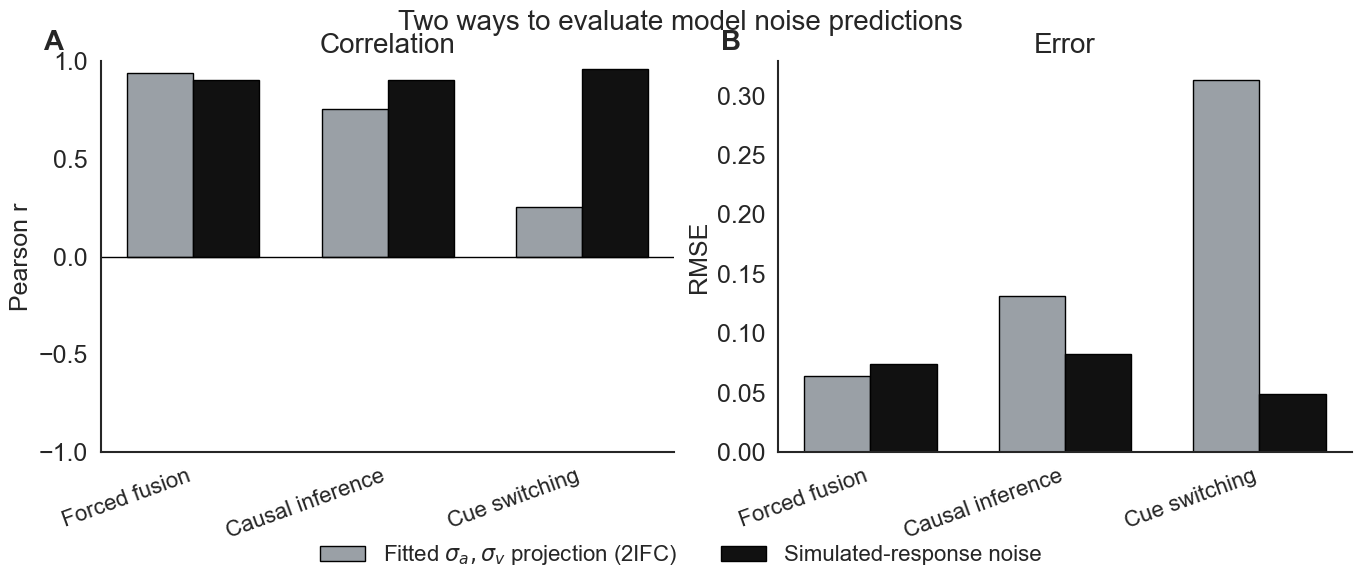

In [16]:
# Compare the two diagnostics directly: raw fitted-sigma projection vs full simulated-response noise.
metric_compare = pd.concat([
    corr_df.assign(metric="Fitted $\\sigma_a,\\sigma_v$ projection (2IFC)"),
    sim_corr_df.assign(metric="Simulated-response noise"),
], ignore_index=True)

fig, axes = plt.subplots(1, 2, figsize=(13.5, 5.2), constrained_layout=True)
bar_width = 0.34
x = np.arange(len(MODEL_ORDER))
metric_offsets = {
    "Fitted $\\sigma_a,\\sigma_v$ projection (2IFC)": -bar_width / 2,
    "Simulated-response noise": bar_width / 2,
}
metric_colors = {
    "Fitted $\\sigma_a,\\sigma_v$ projection (2IFC)": "#9aa0a6",
    "Simulated-response noise": "#111111",
}

for metric, offset in metric_offsets.items():
    sub = metric_compare[metric_compare["metric"] == metric].set_index("model").loc[MODEL_ORDER]
    axes[0].bar(x + offset, sub["pearson_r"], width=bar_width, color=metric_colors[metric], edgecolor="black", linewidth=1.0, label=metric)
    axes[1].bar(x + offset, sub["rmse"], width=bar_width, color=metric_colors[metric], edgecolor="black", linewidth=1.0, label=metric)

axes[0].set_ylabel("Pearson r")
axes[0].set_ylim(-1, 1)
axes[0].axhline(0, color="black", lw=1)
axes[0].set_title("Correlation")
axes[1].set_ylabel("RMSE")
axes[1].set_title("Error")

for ax in axes:
    ax.set_xticks(x)
    ax.set_xticklabels([MODEL_STYLE[m]["label"] for m in MODEL_ORDER], rotation=20, ha="right", fontsize=FONT_SIZE_LABEL - 2)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

handles, labels = axes[1].get_legend_handles_labels()
fig.legend(handles, labels, frameon=False, loc="lower center", ncol=2, bbox_to_anchor=(0.5, -0.08), fontsize=FONT_SIZE_LEGEND - 2)
fig.suptitle("Two ways to evaluate model noise predictions", y=1.03, fontsize=FONT_SIZE_TITLE)
add_panel_labels(axes, x=-0.10, y=1.08)

for out_path in MODEL_METRIC_COMPARE_OUT_PATHS:
    fig.savefig(out_path, dpi=400, bbox_inches="tight")
    print(f"Saved {out_path.relative_to(ROOT)}")

plt.show()